# NB2 — Transfermarkt Enrichment + Madrid Squad Needs

Two jobs:
1. Role + value enrichment — match the FBref pool to Transfermarkt `players.csv` on
   *name + birth year*, replace the rough FBref position heuristic with the real `sub_position`
   (unlocking CB-vs-FB and `defensive_mid`), and attach `market_value_eur`. This makes the
   defender scores real and gives NB3 a value to rank against.
2. Madrid squad-needs profile (descriptive) — Madrid's *current* squad by role, age, and value,
   to show where the gaps and ageing spots are. (Originally planned a transfer history from
   `transfers.csv`, but that file is too incomplete for recent signings. It holds only ~22 RM
   incoming rows ever and is missing Militão, Camavinga, Tchouaméni, Bellingham, etc. The current
   squad from `players.csv` is reliable and more useful for spotting gaps to fill.)

Inputs: `data/transformed/fbref_merged.csv` (from NB1) and `data/raw/transfers/players.csv`.
Run order: NB1 → **NB2** → re-run `scoring.py` → NB3. Re-running NB1 means re-running NB2.

In [1]:
import json, unicodedata
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRANS = ROOT/"data"/"transformed"
RAWTM = ROOT/"data"/"raw"/"transfers"
PLOTS = ROOT/"assets"/"plots"; PLOTS.mkdir(parents=True, exist_ok=True)
WEIGHTS = ROOT/"config"/"mourinho_weights.json"

VALUE_FIELD = "highest_market_value_in_eur"      # peak-era proxy (fits the 2020-23 window)
RM_NAME     = "Real Madrid Club de Fútbol"       # exact current_club_name in players.csv
BY_TOL      = 1                                  # birth-year tolerance for disambiguation

## Step 1 — Load players.csv and the FBref pool

In [2]:
players = pd.read_csv(RAWTM/"players.csv", low_memory=False)
pool = pd.read_csv(TRANS/"fbref_merged.csv")
print("players.csv", players.shape)
print("fbref pool ", pool.shape, "| roles:", pool['role'].nunique())

players.csv (47701, 26)
fbref pool  (7222, 39) | roles: 5


## Step 2 — Normaliser, role map, birth years on both sides

FBref age is the age at the season start, so birth_year ≈ `Season_End_Year - 1 - Age`
(±1 for birth month). Used only to disambiguate same-name players.

In [3]:
def norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode().lower().strip()
    return " ".join(s.split())

pmap_raw = json.load(open(WEIGHTS, encoding="utf-8"))["_position_map"]
POS_MAP = {k: v for k, v in pmap_raw.items() if not k.startswith("_") and v != "EXCLUDE"}

# TM candidates: (birth_year, role, value) per normalised name
tm = players.copy()
tm["_k"]   = tm["name"].map(norm)
tm["_by"]  = pd.to_datetime(tm["date_of_birth"], errors="coerce").dt.year
tm["_role"]= tm["sub_position"].map(POS_MAP)
tm["_val"] = pd.to_numeric(tm[VALUE_FIELD], errors="coerce")
tm = tm[tm["_role"].notna()]                     # outfield only (drops GK + unmapped)
candidates = defaultdict(list)
for k, by, role, val in zip(tm["_k"], tm["_by"], tm["_role"], tm["_val"]):
    candidates[k].append((by, role, val))
print(f"TM outfield candidates: {len(tm):,} across {len(candidates):,} unique names")

rep = pool.loc[pool.groupby("Url")["Min_Playing"].idxmax()].copy()
rep["_k"]      = rep["Player"].map(norm)
rep["_by_est"] = rep["Season_End_Year"] - 1 - rep["Age"].astype("Float64")
print("FBref unique players:", len(rep))

TM outfield candidates: 41,719 across 40,613 unique names
FBref unique players: 3738


## Step 3 — Match: unique name → take it; ambiguous name → break tie by birth year

In [4]:
def resolve(k, by_est):
    cands = candidates.get(k, [])
    if not cands:
        return (None, np.nan, "fbref")
    if len(cands) == 1:
        _, role, val = cands[0]
        return (role, val, "tm")
    if pd.isna(by_est):
        return (None, np.nan, "fbref")
    best, bestd = None, 99
    for by, role, val in cands:
        if pd.isna(by):
            continue
        d = abs(by - by_est)
        if d < bestd:
            best, bestd = (role, val), d
    if best is not None and bestd <= BY_TOL:
        return (best[0], best[1], "tm")
    return (None, np.nan, "fbref")

res = rep.apply(lambda r: resolve(r["_k"], r["_by_est"]), axis=1, result_type="expand")
res.columns = ["tm_role", "tm_val", "src"]
rep = pd.concat([rep.reset_index(drop=True), res.reset_index(drop=True)], axis=1)
n_amb = sum(len(v) > 1 for v in candidates.values())
print(f"match rate: {(rep['src']=='tm').mean():.1%} ({(rep['src']=='tm').sum()}/{len(rep)})")
print(f"ambiguous TM names (>1 player): {n_amb:,} — resolved via birth year")

match rate: 90.5% (3384/3738)
ambiguous TM names (>1 player): 778 — resolved via birth year


## Step 4 — Apply enrichment to the pool + tier files

In [5]:
url2role = dict(zip(rep["Url"], rep["tm_role"]))
url2val  = dict(zip(rep["Url"], rep["tm_val"]))
url2src  = dict(zip(rep["Url"], rep["src"]))

before = pool["role"].value_counts()
pool["role_source"]      = pool["Url"].map(url2src).fillna("fbref")
pool["market_value_eur"] = pool["Url"].map(url2val)
tm_role_col = pool["Url"].map(url2role)
pool["role"] = tm_role_col.where(pool["role_source"] == "tm", pool["role"])
after = pool["role"].value_counts()

print("ROLE distribution (before -> after):")
for r in sorted(set(before.index) | set(after.index)):
    print(f"  {r:14s} {before.get(r,0):5d} -> {after.get(r,0):5d}")
print(f"\nmarket value coverage in pool: {pool['market_value_eur'].notna().mean():.0%}")

pool.to_csv(TRANS/"pool_enriched.csv", index=False)
for t in ["A","B","C"]:
    pool[pool["tier"] == t].to_csv(TRANS/f"tier_{t}_players.csv", index=False)
print("overwrote tier_A/B/C_players.csv with enriched roles + value; wrote pool_enriched.csv")

ROLE distribution (before -> after):
  center_back     2398 ->  1520
  central_mid     2253 ->  1231
  defensive_mid      0 ->   644
  full_back        407 ->  1168
  striker          827 ->  1069
  wide_attacker   1337 ->  1590

market value coverage in pool: 92%
overwrote tier_A/B/C_players.csv with enriched roles + value; wrote pool_enriched.csv


## Step 5 — Real Madrid current squad

`players.csv` `current_club_name` is reliable. Kept current outfielders and read the squad
shape by role. Thin or ageing roles are where Mourinho-fit targets matter.

In [6]:
sq = players[players["current_club_name"].eq(RM_NAME)].copy()
sq = sq[sq["last_season"] >= 2024]                              # drop stale/departed entries
sq["age"]  = ((pd.Timestamp("2025-07-01") - pd.to_datetime(sq["date_of_birth"], errors="coerce")).dt.days/365.25).round(0)
sq["role"] = sq["sub_position"].map(POS_MAP)
sq["valM"] = (pd.to_numeric(sq[VALUE_FIELD], errors="coerce")/1e6).round(1)
sq = sq[sq["role"].notna()]                                     # outfield only

squad = sq[["name","sub_position","role","age","valM"]].sort_values("valM", ascending=False).reset_index(drop=True)
squad.to_csv(TRANS/"madrid_squad_profile.csv", index=False)
print(f"current senior outfield squad: {len(squad)} players")
print(squad.to_string(index=False))

current senior outfield squad: 36 players
                  name       sub_position          role  age  valM
         Kylian Mbappé     Centre-Forward       striker 27.0 200.0
       Vinicius Junior        Left Winger wide_attacker 25.0 180.0
       Jude Bellingham Attacking Midfield wide_attacker 22.0 180.0
     Federico Valverde   Central Midfield   central_mid 27.0 130.0
Trent Alexander-Arnold         Right-Back     full_back 27.0 110.0
               Rodrygo       Right Winger wide_attacker 24.0 110.0
     Eduardo Camavinga   Central Midfield   central_mid 23.0 100.0
   Aurélien Tchouaméni Defensive Midfield defensive_mid 25.0 100.0
          Éder Militão        Centre-Back   center_back 27.0  70.0
           David Alaba        Centre-Back   center_back 33.0  65.0
       Álvaro Carreras          Left-Back     full_back 22.0  60.0
       Daniel Carvajal         Right-Back     full_back 33.0  60.0
       Antonio Rüdiger        Centre-Back   center_back 32.0  50.0
         Ferland Men

In [7]:
needs = sq.groupby("role").agg(n=("name","size"), mean_age=("age","mean")).round(1)
order = list(dict.fromkeys(POS_MAP.values()))
needs = needs.reindex([r for r in order if r in needs.index])
print("squad depth & age by role:"); print(needs.sort_values("mean_age", ascending=False))
print("\nThin (low n) or ageing (high mean_age) roles = priority for the shortlist.")

squad depth & age by role:
                n  mean_age
role                       
full_back       8      25.0
defensive_mid   1      25.0
center_back     9      24.1
striker         2      24.0
central_mid     6      22.8
wide_attacker  10      21.4

Thin (low n) or ageing (high mean_age) roles = priority for the shortlist.


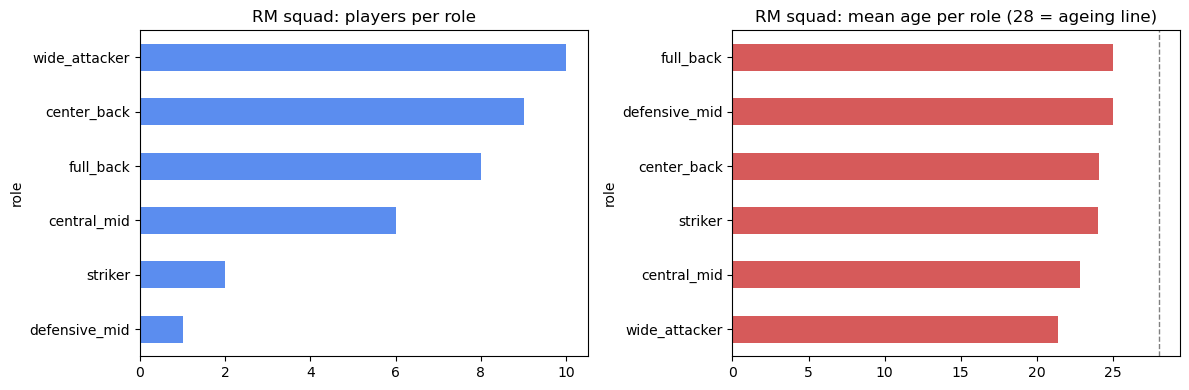

saved c:\Users\Gilbert\Documents\Projects\real-madrid-scouting\assets\plots\madrid_squad.png


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
needs["n"].sort_values().plot(kind="barh", ax=ax[0], color="#5b8def")
ax[0].set_title("RM squad: players per role")
needs["mean_age"].sort_values().plot(kind="barh", ax=ax[1], color="#d65a5a")
ax[1].axvline(28, ls="--", c="grey", lw=1); ax[1].set_title("RM squad: mean age per role (28 = ageing line)")
plt.tight_layout(); plt.savefig(PLOTS/"madrid_squad.png", dpi=120, bbox_inches="tight"); plt.show()
print("saved", PLOTS/"madrid_squad.png")

## Step 6 — Outputs & next step

Written to `data/transformed/`: `pool_enriched.csv`, overwritten `tier_A/B/C_players.csv`
(correct roles + `market_value_eur`), `madrid_squad_profile.csv`; plot in `assets/plots/`.

**Re-run `scoring.py`** — it reads the enriched tier files, so defender scores become real,
`defensive_mid` appears, and `market_value_eur` flows through for NB3's score-for-value ranking.